In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
# JAX will sometimes print a warning about not finding a cuda device when it is first imported or run. 
# Don't worry, it will default to CPU

import jax
import jax.numpy as jnp
import numpy as np
import equinox as eqx
import matplotlib.pyplot as plt
from tqdm import tqdm, trange

# Synthetic data and model

We will first make a **true** version of our system. This let's us transform random input data into synthetic target data that we will train our ML model to predict. I just chose the weights and bias at random. 

This model is just a linear combination of the input features:
$y = w_1x_1 + w_2x_2 + b$

In a real system, this true model is what we are trying to get our ML model to approximate. Of course we won't actually know what this function is, but that is where the real target data comes into play. 

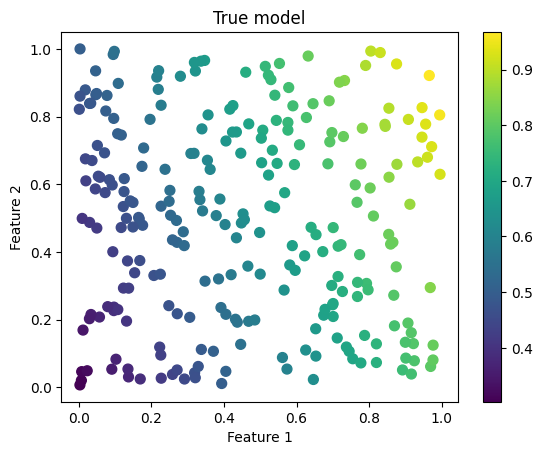

In [2]:
def true_model(x):
    weights = jnp.array([0.5, 0.2])
    bias = 0.3
    return x @ weights + bias

batch_size = 256
in_size = 2
out_size = 1

key = jax.random.PRNGKey(0)
key, x_key, y_key = jax.random.split(key, 3)
x = jax.random.uniform(x_key, (batch_size, in_size))
y = true_model(x)

plt.scatter(x[:,0], x[:,1], 50, y)
plt.title("True model")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar()
plt.show()

# Making a model
Now we are going to initialize a simple linear layer from the package `equinox` as our model. Using the `in_size` and `out_size` parameters we match the dimensions of our synthetic data. The weights and bias of this model are intialized with random values, so we shouldn't expect to to make a good prediciton. 

### An aside on random keys
One thing I left out of the previous block is the use of `key` objects by `equinox`. These are used for the random initialization of the model weights (and for the random input data above). Equinox is very explicit about the use and passing of keys, which is sometimes annoying, but also makes it more reproducable compared to hidden states or seeds managed by the package at a higher level. In order to generate new keys, we use `jax.random.split` which produces 2 new keys. We keep one of these (overwriting as `key`) for the next time we need keys, and consume the other (`model_key`) for our model initialization. By basing all of these keys and splits on the original `jax.random.PRNGKey(0)` in the above block, we can change all of the randomization in our model and data just by changing this first seed. This makes random ensemble modeling fairly easy. 


In [3]:
key, model_key = jax.random.split(key)

model = eqx.nn.Linear(in_size, out_size, key=model_key)
print(model)

Linear(
  weight=f32[1,2], bias=f32[1], in_features=2, out_features=1, use_bias=True
)


## Inspecting our model
Equinox models are just collections of jax.numpy arrays. Above we can see our model contains `weights` with shape (1, 2), `bias` with shape (1), and some static attributes. We can easily view these attributes and their values by accessing the attributes:

In [4]:
print(f"{model.weight = }")
print(f"{model.bias = }")

model.weight = Array([[-0.68400913,  0.4777369 ]], dtype=float32)
model.bias = Array([0.50415826], dtype=float32)


# Making predicitons
Let's make our first set of predictions with the model. Again, the weights and bias are random so it won't be a good model yet.


In [5]:
# When running any model, it's important to keep track of the dimensions of your matrices.
# Let's just quickly look at the shape of the input data
x.shape
# right now it's (256, 2), representing the (batch_size, num_features)

(256, 2)

Text(0, 0.5, 'Feature 2')

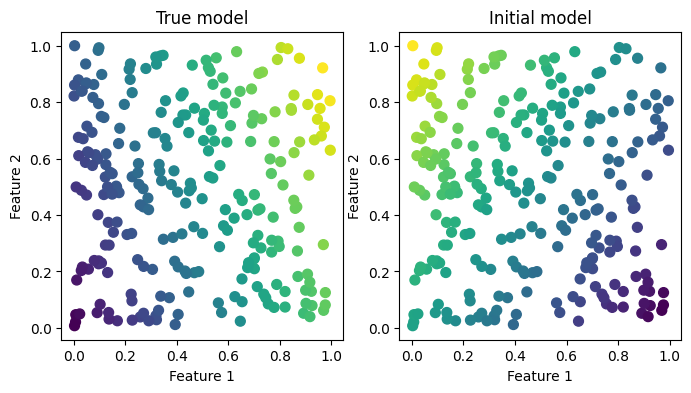

In [6]:
# jax.vmap is a `vector map` over the first dimension of the array. Like a for loop but happens all at once.
# So here, it is applying our model to each of the 256 samples in our batch of data.
pred_y =  jax.vmap(model)(x)

fig, axes = plt.subplots(1,2, figsize=(8,4))
axes[0].scatter(x[:,0], x[:,1], 50, y)
axes[0].set_title("True model")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[1].scatter(x[:,0], x[:,1], 50, pred_y)
axes[1].set_title("Initial model")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

# Training our model
Ok, so our model is bad. The beauty of `JAX` and `Equinox` is that when we define the **forward** call of our model (the equations for inputs -> outputs), the inverse is automatically defined. AND! we can automatically calculate the gradients of the model (outputs -> inputs) and then update our model based on the gradients. This is the basics of backpropagation and is the heart of ML modeling.

In [7]:
# the decorator changes the function to return the loss value AND the gradients of the loss
@eqx.filter_value_and_grad
def loss_fn(model, x, y):
    pred_y = jax.vmap(model)(x)
    return jax.numpy.mean((y - pred_y) ** 2)

loss, grads = loss_fn(model, x, y)

print(f"{loss = :0.4f}\n")
print(f"{grads = }")
# You'll notice the grads object has the same exact structure as our Linear model. 
# Each trainable parameter in the model has a corresponding gradient value here.

loss = 0.1252

grads = Linear(
  weight=f32[1,2], bias=f32[1], in_features=2, out_features=1, use_bias=True
)


## Using the gradients
`optax` is a package developed specifically for JAX, and allows simple gradient based model updates. We just have to setup the optimizer and optimization state (tracks trajectory for multiple steps).

Text(0, 0.5, 'Feature 2')

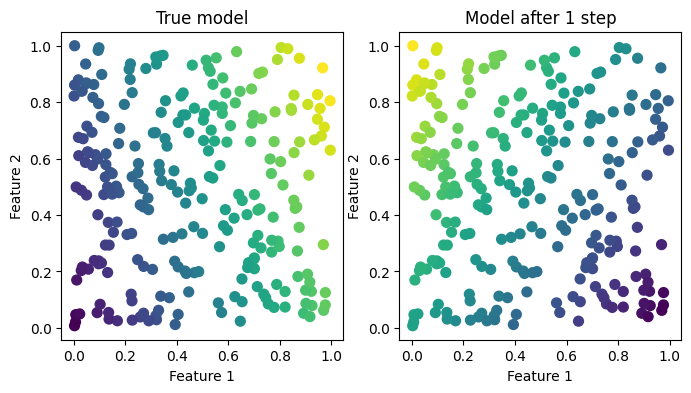

In [8]:
import optax 

learning_rate = 0.001
optim = optax.adam(learning_rate)
opt_state = optim.init(model)

updates, opt_state = optim.update(grads, opt_state)
model = eqx.apply_updates(model, updates)

pred_y =  jax.vmap(model)(x)

fig, axes = plt.subplots(1,2, figsize=(8,4))
axes[0].scatter(x[:,0], x[:,1], 50, y)
axes[0].set_title("True model")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[1].scatter(x[:,0], x[:,1], 50, pred_y)
axes[1].set_title("Model after 1 step")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

## Repeating the updates

100%|██████████| 500/500 [00:00<00:00, 627.58it/s]


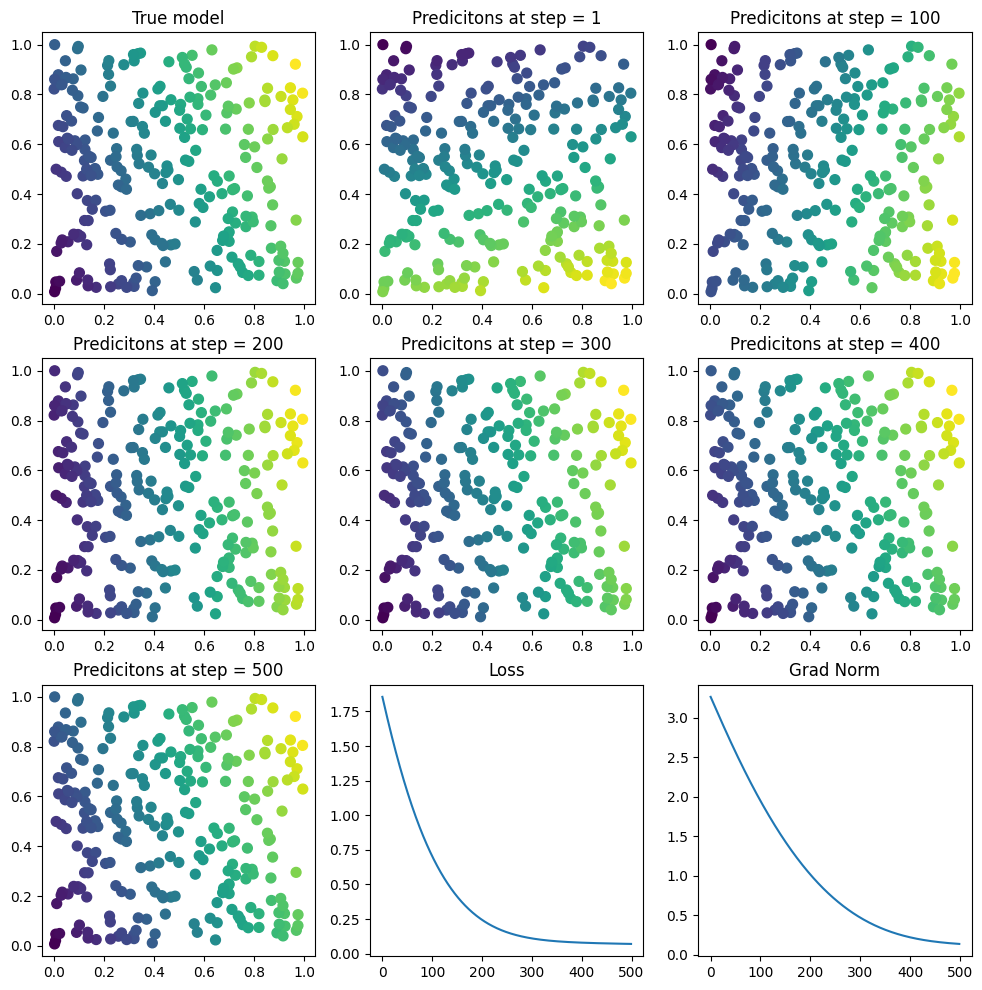

In [9]:
max_iter = 500
learning_rate = 0.003
optim = optax.adam(learning_rate)
opt_state = optim.init(model)

# Remake the step and loss functions for clarity.
# Here we are JIT compiling the make step fn. Try without to compare speed. 
@jax.jit 
def make_step(model, x, y, opt_state):
    loss, grads = loss_fn(model, x, y)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, grads, model, opt_state

@eqx.filter_value_and_grad
def loss_fn(model, x, y):
    pred_y = jax.vmap(model)(x)
    return jax.numpy.mean((y - pred_y) ** 2) 

# Let's start with a fresh model
key = jax.random.PRNGKey(0)
key, model_key = jax.random.split(key)
model = eqx.nn.Linear(in_size, out_size, key=model_key)


#setup our plot
fig, axes = plt.subplots(3,3, figsize=(12,12))
axes = axes.flatten()
axes[0].scatter(x[:,0], x[:,1], 50, y)
axes[0].set_title("True model")
plot_iters = np.linspace(1, max_iter, len(axes)-3, dtype=int)

# Now we will actually train the model.
losses = []
grad_norms = []
for step in trange(1, max_iter+1):
    loss, grads, model, opt_state = make_step(model, x, y, opt_state)
    losses.append(loss)
    grad_norms.append(optax.global_norm(grads))

    if step in plot_iters:
        pred_y =  jax.vmap(model)(x)
        ax_idx = np.where(plot_iters == step)[0][0] + 1
        axes[ax_idx].scatter(x[:,0], x[:,1], 50, pred_y)
        axes[ax_idx].set_title(f"Predicitons at {step = }")

    
axes[-2].plot(losses)
axes[-2].set_title("Loss")
axes[-1].plot(grad_norms)
axes[-1].set_title("Grad Norm")
plt.show()

# Inspecting model post training
If we look at the model weights after training, they are much closer to the weights set in the `true_model`. Not exactly, which is a little surprising given how simple this problem is, but we can see the gradients are starting to get very weak as we approach the solution. The magnitude of these gradients (summarized as the norm here) determines how much the parameters will change in each update. A different loss function or optimization scheme might be able to solve this, but we won't do that now.

In [10]:
print(f"{model.weight = }")
print(f"{model.bias = }")

model.weight = Array([[0.6439001 , 0.27097163]], dtype=float32)
model.bias = Array([0.13944778], dtype=float32)
